In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/ChenPaperCode/ChenvsMe.py"

## Print out df to confirm information is correct

In [3]:
# This should be the cumulitive information from Table 2 
df_cumulative_Chen

,S,N,N(>S),N(>S) err lower,N(>S) err upper
0,0.19,92,21900,3250,3250
1,0.32,84,12950,1640,1640
2,0.52,69,7390,930,930
3,0.86,53,4120,560,560
4,1.43,39,2660,420,420
5,2.36,25,1540,300,370
6,3.91,13,770,210,270
7,6.47,4,230,110,180


In [4]:
# This should be the cumulitive information from Table 2 
df_differential_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper
0,0.25,8,73860,29940,39660
1,0.42,15,28600,8210,10180
2,0.69,16,10230,2670,3350
3,1.15,14,2780,740,960
4,1.90,14,1280,340,440
5,3.14,12,530,150,200
6,5.19,9,220,70,100


## My Code

In [5]:
def Schechter(S, params):
    alpha, S0, N0 = params
    return N0 * (S/S0)**alpha * np.exp(-S/S0)

In [6]:
def DoublePowerLaw(S, params):
    alpha, beta, S0, N0 = params
    return (N0* 3600/S0) * ((S/S0)**alpha + (S/S0)**beta)**-1

In [7]:
def log_residual(params, func, x, y):
    # pass params as a single array (do NOT unpack)
    model = np.array([func(params, xi) for xi in x])
    mask = (model > 0) & (y > 0)
    return np.log10(model[mask]) - np.log10(y[mask])

In [8]:
def log_residual_asym(params, model, x, y, yerr_lower, yerr_upper):
    y_model = model(x, params)  # now order matches
    residuals = np.log10(y) - np.log10(y_model)
    
    sigma = np.where(y_model > y, yerr_upper, yerr_lower)
    sigma_log = sigma / (y * np.log(10))
    
    return residuals / sigma_log

# Fitting Order

I will be doing 4 fits total:

- #1: Schecter Differential
- #2: Double Power Law Differential
- #3: Schecter Cumulative
- #4: Double Power Law Cumulative

Guesses:
- The guesses that I am feeding into the model are based off of the results from the paper
- For Schecter the form is: $\alpha$, $S_0$, $N_0$
- For the double power law the form is $\alpha_1$, $\alpha_2$, $S_0$, $N_0$

In [9]:
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # Differential Schechter (alpha, S0, N0)

Schechter_Diferential_Guess = [-1.7, 3.9, 2.2/3.6]

# Differential DPL (alpha, beta, S0, N0)
DoublePowerLaw_Diferential_Guess = [2.0, 4.7, 5.6, 0.8/3.6]

# Cumulative Schechter (alpha, S0, N0)
Schechter_Cumulative_Guess = [-0.6, 2.2, 9.6/3.6]

# Cumulative DPL (alpha, beta, S0, N0)
DoublePowerLaw_Cumulative_Guess = [1.0, 4.7, 4.5, 3.6/3.6]

In [10]:
# guesses_og = [Schechter_Diferential_Guess, 
#               DoublePowerLaw_Diferential_Guess, 
#               Schechter_Cumulative_Guess, 
#               DoublePowerLaw_Cumulative_Guess]

In [11]:
guess_index = {
    0: ['schechter', 'differential'],
    1: ['dpl', 'differential'],
    2: ['schechter', 'cumulative'],
    3: ['dpl', 'cumulative'],
}

schecter_index = ['alpha', 'S0', 'N0']

dpl_index = ['alpha1', 'alpha2', 'S0', 'N0']

In [12]:
# filling the array using the index

# Make an empty array to fill:
guess_test_array = []

# Loop over each fit 
for i in range(4):
    vals = []
    
    # Get the model and kind
    model, kind = guess_index[i]
    
    if model == 'schechter':
        for variable in schecter_index:
            vals.append(BestFitValues[model][kind][variable])
    
    
    elif model == 'dpl':
        
        for variable in dpl_index:
            vals.append(BestFitValues[model][kind][variable])
            
    guess_test_array.append(vals)

In [13]:
# # comparing

# # Loop over the number of fits
# for i in range(4):
#     guess_original = guesses_og[i]
#     guess_test = guess_test_array[i]
    
#     print(rf'Guess {i}')
#     # Loop over the values in the arrays
#     for j in range(len(guess_test)):
#         og = guess_original[j]
#         test = guess_test[j]
#         diff = np.abs(og - test)
        
#         print(rf'      og value: {og:.2f} and test value: {test:.2f} and difference: {diff:.2f}')
        


In [14]:
guess = guess_test_array
# guess = guesses_og

# --- Differential Schechter ---
results1 = least_squares(log_residual_asym,
                         guess[0],
                         args=(Schechter, *differential_data))

# --- Differential Double Power Law ---
results2 = least_squares(log_residual_asym,
                         guess[1],
                         args=(DoublePowerLaw, *differential_data),
                         bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf]))

# --- Cumulative Schechter ---
results3 = least_squares(log_residual_asym,
                         guess[2],
                         args=(Schechter, *cumulative_data))



# --- Cumulative Double Power Law ---
results4 = least_squares(log_residual_asym,
                         guess[3],
                         args=(DoublePowerLaw, *cumulative_data),
                         bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf]))


In [15]:
# Print resilts
print("\n===== FIT RESULTS =====")

print("Differential Schechter:")
print("     Guess  : alpha = %.3f, S0 = %.3g, N0 = %.3g" % tuple(guess[0]))
print("     Results: alpha = %.3f, S0 = %.3g, N0 = %.3g" % tuple(results1.x))
print(" ")

print("Differential DPL:")
print("     Guess  : alpha = %.3f, beta = %.3f,S0 = %.3g, N0 = %.3g" % tuple(guess[1]))
print("     Results: alpha = %.3f, beta = %.3f,S0 = %.3g, N0 = %.3g" % tuple(results2.x))
print(" ")

print("Cumulative Schechter:")
print("     Guess  : alpha = %.3f, S0 = %.3g, N0 = %.3g" % tuple(guess[2]))
print("     Results: alpha = %.3f, S0 = %.3g, N0 = %.3g" % tuple(results3.x))
print(" ")

print("Cumulative DPL:")
print("     Guess  : alpha = %.3f, beta = %.3f, S0 = %.3g, N0 = %.3g" % tuple(guess[3]))
print("     Results: alpha = %.3f, beta = %.3f,S0 = %.3g, N0 = %.3g" % tuple(results4.x))
print(" ")


===== FIT RESULTS =====
Differential Schechter:
     Guess  : alpha = -1.700, S0 = 3.9, N0 = 2.2
     Results: alpha = -1.945, S0 = 2.07e+03, N0 = 0.00171
 
Differential DPL:
     Guess  : alpha = 2.000, beta = 4.700,S0 = 5.6, N0 = 0.8
     Results: alpha = 1.946, beta = 1.946,S0 = 4.74, N0 = 0.616
 
Cumulative Schechter:
     Guess  : alpha = -0.600, S0 = 2.2, N0 = 9.6
     Results: alpha = -1.008, S0 = 12.1, N0 = 331
 
Cumulative DPL:
     Guess  : alpha = 1.000, beta = 4.700, S0 = 4.5, N0 = 3.6
     Results: alpha = 1.064, beta = 5.889,S0 = 6.19, N0 = 0.925
 


In [16]:
# S_grid = np.linspace(0.05, 30, 1000)

# This is from Chen 2022
S_grid = np.logspace(-2, 1.5, 100)


schechter_fit_diff_paper = Schechter(S_grid, Schechter_Diferential_Guess) * S_grid**2.5

# Evaluate best-fit models


# schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 


schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 


## Plot

In [17]:
# Set colors 
# ---------------------------------------------
my_line_color = 'tab:red'
chen_line_color = 'tab:cyan'

my_schechter_fit_colour = 'orchid'
my_dpl_fit_colour = 'palegreen'

my_data_point_color = 'green'
chen_data_point_color = 'darkblue'
# ---------------------------------------------



# Line styles
# ---------------------------------------------
my_schechter_fit_ls = (0, (10, 5))
my_dpl_fit_ls = (0, (1, 1))
# ---------------------------------------------


# Line width
# ---------------------------------------------
my_schechter_fit_lw = 7
my_dpl_fit_lw = 7
# ---------------------------------------------



# ls = ['-', '--', '-.', ':', 
#        (0, (1, 1)), 
#       #(0, (3, 10, 1, 10, 1, 10)),
#       (0, (3, 1, 1, 1, 1, 1)), 
#       '-', '-', '-', '-', '-', '-']


# planck_ls = ['-', '--', '-.', ':', 
#       (0, (10, 5)), 
#        (0, (1, 1)), 
#       (0, (3, 1, 1, 1, 1, 1)), 
#       '-', '-', '-', '-', '-', '-']

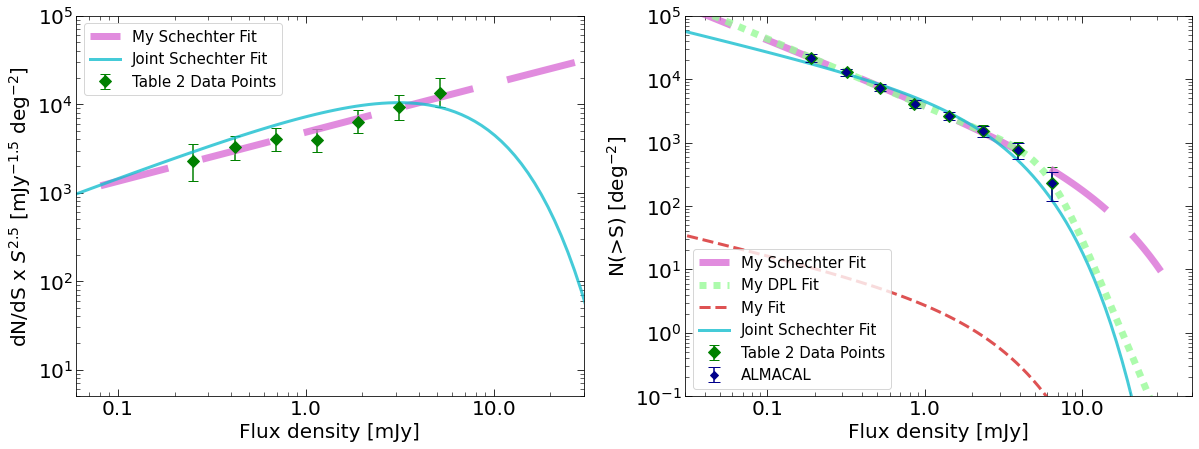

In [18]:
fig, ax = plot_Chen2022()



# Plot my fit solutions using results
# ------------------------------------------------------------------------------------
# --- Differential Schechter ---
ax[0].plot(S_grid, 
           Schechter(S_grid, results1.x) * S_grid**2.5,
           color = my_schechter_fit_colour, 
           alpha = 0.8, 
           ls = my_schechter_fit_ls,
           lw = my_schechter_fit_lw,
           label = rf'My Schechter Fit')



# --- Differential Double Power Law ---
# ax[0].plot(S_grid, 
#            DoublePowerLaw(S_grid, results2.x) * S_grid**2.5,
#            color = my_dpl_fit_colour, 
#            alpha = 0.8, 
#            ls = my_dpl_fit_ls, 
#            lw = my_dpl_fit_lw, 
#            label = rf'My DPL Fit')


# --- Cumulative Schechter ---
ax[1].plot(S_grid, 
           Schechter(S_grid, results3.x),
           color = my_schechter_fit_colour, 
           alpha = 0.8, 
           ls = my_schechter_fit_ls, 
           lw = my_schechter_fit_lw,  
           label = rf'My Schechter Fit')


# --- Cumulative Double Power Law ---
ax[1].plot(S_grid, 
           DoublePowerLaw(S_grid, results4.x),
           color = my_dpl_fit_colour, 
           alpha = 0.8, 
           ls = my_dpl_fit_ls, 
           lw = my_dpl_fit_lw,
           label = rf'My DPL Fit')





# --------------------------------------------------------------------
# ------------------------------------------------------------------------------------


# Plot my fit solutions
# ------------------------------------------------------------------------------------
test_fit_inputs = np.array([
    guess_test_array[0],
    # results1.x,   # uncomment if you want this one too
    Schechter_Diferential_Guess,
    [-1.7, 3.9, 1],
])

B7_x_fitted = np.logspace(-2, 1.5, 100)

test_fit_colors = sns.color_palette('tab10', len(test_fit_inputs))

ls = ['-', '--', ':']


# for i in range(len(test_fit_inputs)):
#     print(rf'i = {i}, params = {test_fit_inputs[i]}')
#     ax[0].plot(S_grid, 
#                S_grid**2.5 *Schechter(S_grid, test_fit_inputs[i]), 
#                color=test_fit_colors[i], 
#                alpha = 0.8, 
#                ls = '--',  
#                lw=3, 
#                label = rf'Test Fit {i}')


# ax[0].plot(S_grid, 
#            schechter_fit_diff_paper, 
#            color=my_line_color, 
#            alpha = 0.8, 
#            ls = '--',  
#            lw=3, 
#            label='My Fit')
ax[1].plot(S_grid, schechter_fit_cumulative_paper, color=my_line_color, alpha = 0.8, ls = '--', lw=3, label='My Fit')
# ------------------------------------------------------------------------------------

# Commented out lines
# ------------------------------------------------------------------------------------
# ax[0].plot(, color=chen_line_color, alpha = 0.8,  lw=3, label='Paper Code')
# ------------------------------------------------------------------------------------


# Paper Data
B7_x_fitted = np.logspace(-2, 1.5, 100)
yf = B7_x_fitted**2.5
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. the alpha definite is a bit different here, see the schechter function in the beginning
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1, S0, N0], N0 here in mJy/arcmin2
ax[0].plot(B7_x_fitted, 
        yf*schechter_chencode(B7_x_fitted, *B7_schechter_diffsols[:-1]), 
        color='tab:cyan', 
        linewidth=3, 
        alpha=0.8, 
        label='Joint Schechter Fit')



# Read ALMACAL number counts
almacal_B7 = Table.read('data/B7_bus-False_diff.txt', format='ascii')

yf = (almacal_B7['flist']*S_alma_scale['B7'])**2.5

# ax[0].errorbar(almacal_B7['flist']*S_alma_scale['B7'], 
#             yf*almacal_B7['dN'], 
#             yerr=[yf*almacal_B7['dNerr_lower'], 
#                   yf*almacal_B7['dNerr_upper']], 
#             label='ALMACAL', 
#             markersize=6, 
#             marker='D', 
#             capsize=6.0, 
#             linestyle="none", 
#             color='darkblue')
# ------------------------------------------------------------------------------------



# ------------------------------------------------------------------------------------
B7_flux_fitted = np.logspace(-2, 1.5, 100)
# plot the best fitting
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. 
# The alpha definite is a bit different here as the paper, see the schechter function in the beginning
B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1, S0, N0]

ax[1].plot(B7_flux_fitted, 
        schechter_chencode(B7_flux_fitted, *B7_schechter_sols), 
        linewidth=3., 
        alpha=0.8, 
        color='tab:cyan', 
        label='Joint Schechter Fit')

almacal_B7 = Table.read('data/B7_bus-False.txt', format='ascii')
#almacal_B7 = Table.read('tests/B7_number_counts_v5.1_py3.txt', format='ascii')
ax[1].errorbar(almacal_B7['flist']*S_almacal_B7toS870, almacal_B7['N'], yerr=almacal_B7['Nerr_lower'], label='ALMACAL',
            markersize=6, marker='D', capsize=6.0, linestyle="none", color='darkblue')
# ------------------------------------------------------------------------------------

for i in range(2):
    ax[i].legend(fontsize = legend_text_fs)

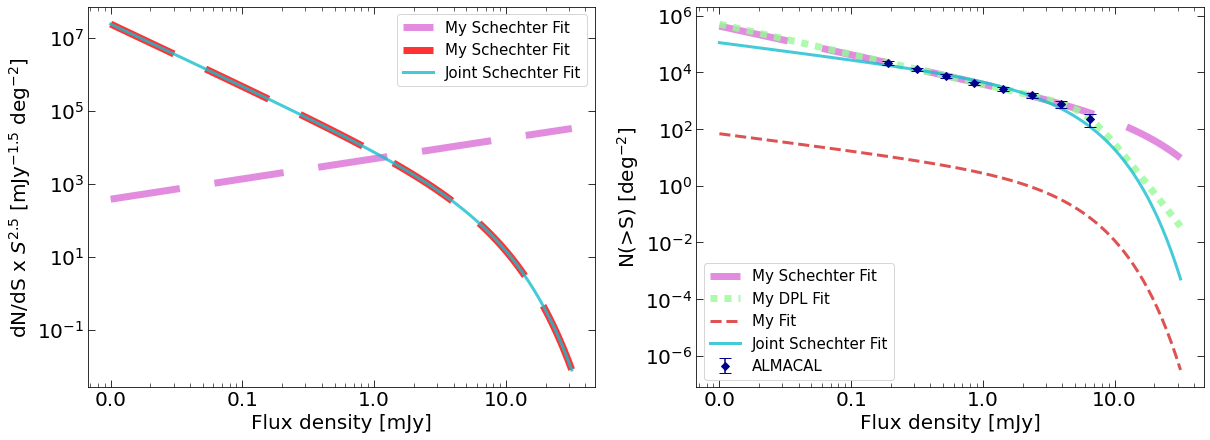

In [19]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# Set colors 
# ---------------------------------------------
my_line_color = 'tab:red'
chen_line_color = 'tab:cyan'

my_data_point_color = 'green'
chen_data_point_color = 'darkblue'
# ---------------------------------------------


# Plot my fit solutions using results
# ------------------------------------------------------------------------------------
# --- Differential Schechter ---
ax[0].plot(S_grid, 
           Schechter(S_grid, results1.x) * S_grid**2.5,
           color = my_schechter_fit_colour, 
           alpha = 0.8, 
           ls = my_schechter_fit_ls,
           lw = my_schechter_fit_lw,
           label = rf'My Schechter Fit')


# --- Differential Schechter ---
ax[0].plot(S_grid, 
           Schechter(S_grid, [-1.7, 3.9, 923]) ,
           color = 'red', 
           alpha = 0.8, 
           ls = my_schechter_fit_ls,
           lw = my_schechter_fit_lw,
           label = rf'My Schechter Fit')



# --- Differential Double Power Law ---
# ax[0].plot(S_grid, 
#            DoublePowerLaw(S_grid, results2.x) * S_grid**2.5,
#            color = my_dpl_fit_colour, 
#            alpha = 0.8, 
#            ls = my_dpl_fit_ls, 
#            lw = my_dpl_fit_lw, 
#            label = rf'My DPL Fit')


# --- Cumulative Schechter ---
ax[1].plot(S_grid, 
           Schechter(S_grid, results3.x),
           color = my_schechter_fit_colour, 
           alpha = 0.8, 
           ls = my_schechter_fit_ls, 
           lw = my_schechter_fit_lw,  
           label = rf'My Schechter Fit')


# --- Cumulative Double Power Law ---
ax[1].plot(S_grid, 
           DoublePowerLaw(S_grid, results4.x),
           color = my_dpl_fit_colour, 
           alpha = 0.8, 
           ls = my_dpl_fit_ls, 
           lw = my_dpl_fit_lw,
           label = rf'My DPL Fit')





# --------------------------------------------------------------------
# ------------------------------------------------------------------------------------


# Plot my fit solutions
# ------------------------------------------------------------------------------------
test_fit_inputs = np.array([
    guess_test_array[0],
    # results1.x,   # uncomment if you want this one too
    Schechter_Diferential_Guess,
    [-1.7, 3.9, 1],
])

B7_x_fitted = np.logspace(-2, 1.5, 100)

test_fit_colors = sns.color_palette('tab10', len(test_fit_inputs))

ls = ['-', '--', ':']


# for i in range(len(test_fit_inputs)):
#     print(rf'i = {i}, params = {test_fit_inputs[i]}')
#     ax[0].plot(S_grid, 
#                S_grid**2.5 *Schechter(S_grid, test_fit_inputs[i]), 
#                color=test_fit_colors[i], 
#                alpha = 0.8, 
#                ls = '--',  
#                lw=3, 
#                label = rf'Test Fit {i}')


# ax[0].plot(S_grid, 
#            schechter_fit_diff_paper, 
#            color=my_line_color, 
#            alpha = 0.8, 
#            ls = '--',  
#            lw=3, 
#            label='My Fit')
ax[1].plot(S_grid, schechter_fit_cumulative_paper, color=my_line_color, alpha = 0.8, ls = '--', lw=3, label='My Fit')
# ------------------------------------------------------------------------------------

# Commented out lines
# ------------------------------------------------------------------------------------
# ax[0].plot(, color=chen_line_color, alpha = 0.8,  lw=3, label='Paper Code')
# ------------------------------------------------------------------------------------


# Paper Data
B7_x_fitted = np.logspace(-2, 1.5, 100)
yf = B7_x_fitted**2.5
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. the alpha definite is a bit different here, see the schechter function in the beginning
B7_schechter_diffsols = [-2.7, 3.9, 0.61] # [alpha-1, S0, N0], N0 here in mJy/arcmin2
ax[0].plot(B7_x_fitted, 
        schechter_chencode(B7_x_fitted, *B7_schechter_diffsols[:-1]), 
        color='tab:cyan', 
        linewidth=3, 
        alpha=0.8, 
        label='Joint Schechter Fit')



# Read ALMACAL number counts
almacal_B7 = Table.read('data/B7_bus-False_diff.txt', format='ascii')

yf = (almacal_B7['flist']*S_alma_scale['B7'])**2.5

# ax[0].errorbar(almacal_B7['flist']*S_alma_scale['B7'], 
#             yf*almacal_B7['dN'], 
#             yerr=[yf*almacal_B7['dNerr_lower'], 
#                   yf*almacal_B7['dNerr_upper']], 
#             label='ALMACAL', 
#             markersize=6, 
#             marker='D', 
#             capsize=6.0, 
#             linestyle="none", 
#             color='darkblue')
# ------------------------------------------------------------------------------------



# ------------------------------------------------------------------------------------
B7_flux_fitted = np.logspace(-2, 1.5, 100)
# plot the best fitting
# scale_N0 = 3600/1000 # from Jy/arcmin2 to mJy/deg2
# note that the values below are copied from the bestfitting. 
# The alpha definite is a bit different here as the paper, see the schechter function in the beginning
B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1, S0, N0]

ax[1].plot(B7_flux_fitted, 
        schechter_chencode(B7_flux_fitted, *B7_schechter_sols), 
        linewidth=3., 
        alpha=0.8, 
        color='tab:cyan', 
        label='Joint Schechter Fit')

almacal_B7 = Table.read('data/B7_bus-False.txt', format='ascii')
#almacal_B7 = Table.read('tests/B7_number_counts_v5.1_py3.txt', format='ascii')
ax[1].errorbar(almacal_B7['flist']*S_almacal_B7toS870, almacal_B7['N'], yerr=almacal_B7['Nerr_lower'], label='ALMACAL',
            markersize=6, marker='D', capsize=6.0, linestyle="none", color='darkblue')
# ------------------------------------------------------------------------------------




# Set y-axis labels 
# ----------------------------------------------------------------------------------------------
ax[0].set_ylabel('dN/dS x $S^{2.5}$ [mJy$^{-1.5}$ deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)
# ----------------------------------------------------------------------------------------------

# Add an x-label, proper ticks on axes and add a legend
# ----------------------------------------------------------------------------------------------
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)

    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")
# ----------------------------------------------------------------------------------------------
    
# Set the bounds
# ------------------------------------------
# Bounds of left plot from the paper code
# ax[0].set_xlim(0.06, 30)
# ax[0].set_ylim(5., 1e5)
# # ------------------------------------------
# # Bounds of right plot from the paper code
# ax[1].set_xlim(0.03, 50)
# ax[1].set_ylim(0.1, 10**5)
# # ------------------------------------------